# **FEATURE ENGINEERING NOTEBOOK**

## **0. Library import**

In [1]:
import os
import sys

# Add the root path into the python path
root_path = os.path.abspath(os.path.join(".."))
if not root_path in sys.path:
    sys.path.insert(0, root_path)

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.features import DiabetesFeatureEngineering
from src.visualization import plot_correlation_matrix
from src.config import BRFSS_CLEANED_FILE_PATH, LOG_DIR

## **1. Load dataset**

In [3]:
# Load preprocessed BRFSS dataset for feature engineering
df = pd.read_csv(filepath_or_buffer=BRFSS_CLEANED_FILE_PATH)
df.drop("Year", axis=1, inplace=True)
df.shape

(452655, 33)

## **2. Feature engineering**

In [4]:
diabetes_feature_engineering = DiabetesFeatureEngineering(log_file=f"{LOG_DIR}/3_feature_engineering.log")

2025-09-27 20:47:26,328 - [src.features] - INFO - Enhanced DiabetesFeatureEngineering initialized successfully


### **2.1 Remove null values**

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 452655 entries, 0 to 452654
Data columns (total 33 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes              452655 non-null  float64
 1   HighBP                452655 non-null  float64
 2   HighChol              452655 non-null  float64
 3   CholCheck             452655 non-null  float64
 4   BMI                   452655 non-null  float64
 5   Smoker                452655 non-null  float64
 6   Stroke                452655 non-null  float64
 7   HeartDiseaseorAttack  452655 non-null  float64
 8   PhysActivity          452655 non-null  float64
 9   HvyAlcoholConsump     452655 non-null  float64
 10  AnyHealthcare         452655 non-null  float64
 11  NoDocbcCost           452655 non-null  float64
 12  GenHlth               452655 non-null  float64
 13  MentHlth              452655 non-null  float64
 14  PhysHlth              452655 non-null  float64
 15  

In [6]:
# Step 1: Check and remove null values (data quality assurance)
clean_df = diabetes_feature_engineering.remove_null_values(df=df)

2025-09-27 20:47:26,378 - [src.features] - INFO - Starting null values removal process...
2025-09-27 20:47:26,402 - [src.features] - INFO - No null values found in the dataset
2025-09-27 20:47:26,474 - [src.features] - INFO - Null values removal completed. Removed 0 rows (0.00%)
2025-09-27 20:47:26,474 - [src.features] - INFO - Dataset shape: 452655 -> 452655 rows


In [7]:
clean_df.isnull().sum()

Diabetes                0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
Depression              0
CognitiveIssues         0
KidneyDisease           0
DiagnosedHeartAttack    0
CoronaryHeartDisease    0
COPD                    0
AlcoholDays             0
LastCheckup             0
HasPersonalDoctor       0
CholesterolMeds         0
MaritalStatus           0
EmploymentStatus        0
CannotAffordDoctor      0
dtype: int64

### **2.2 Remove duplicate values**

In [8]:
# Before removing duplicate rows
clean_df.shape

(452655, 33)

In [9]:
# Step 2: Remove duplicate records to prevent overfitting
no_dup_df = diabetes_feature_engineering.remove_duplicates(df=clean_df)

2025-09-27 20:47:26,520 - [src.features] - INFO - Starting duplicate removal process...
2025-09-27 20:47:26,807 - [src.features] - INFO - Found 3450 duplicate rows
2025-09-27 20:47:26,874 - [src.features] - INFO -   - Label 2.0: 211 duplicate rows
2025-09-27 20:47:27,097 - [src.features] - INFO -   - Label 0.0: 3228 duplicate rows
2025-09-27 20:47:27,113 - [src.features] - INFO -   - Label 1.0: 11 duplicate rows
2025-09-27 20:47:27,437 - [src.features] - INFO - Duplicate removal completed. Removed 3450 rows (0.76%)
2025-09-27 20:47:27,438 - [src.features] - INFO - Dataset shape: 452655 -> 449205 rows


In [10]:
# After removing duplicate rows
no_dup_df.shape

(449205, 33)

### **2.3 Handle outliers**

In [11]:
# Step 3: Handle outliers using IQR method for BMI, MentHlth, PhysHlth
outliers_df = diabetes_feature_engineering.handle_outliers(df=no_dup_df)

2025-09-27 20:47:27,455 - [src.features] - INFO - Starting enhanced outlier handling process...
2025-09-27 20:47:27,456 - [src.features] - INFO - Columns to process: ['BMI', 'MentHlth', 'PhysHlth', 'AlcoholDays']
2025-09-27 20:47:27,483 - [src.features] - INFO - Processing outliers for column: BMI
2025-09-27 20:47:27,548 - [src.features] - INFO -   - Diabetes group 2.0: 2024 outliers (Lower: 9, Upper: 2015)
2025-09-27 20:47:27,684 - [src.features] - INFO -   - Diabetes group 0.0: 11891 outliers (Lower: 63, Upper: 11828)
2025-09-27 20:47:27,706 - [src.features] - INFO -   - Diabetes group 1.0: 554 outliers (Lower: 22, Upper: 532)
2025-09-27 20:47:27,710 - [src.features] - INFO - Processing outliers for column: MentHlth
2025-09-27 20:47:27,762 - [src.features] - INFO -   - Diabetes group 2.0: 13244 outliers (Lower: 0, Upper: 13244)
2025-09-27 20:47:27,920 - [src.features] - INFO -   - Diabetes group 0.0: 53646 outliers (Lower: 0, Upper: 53646)
2025-09-27 20:47:27,943 - [src.features] - I

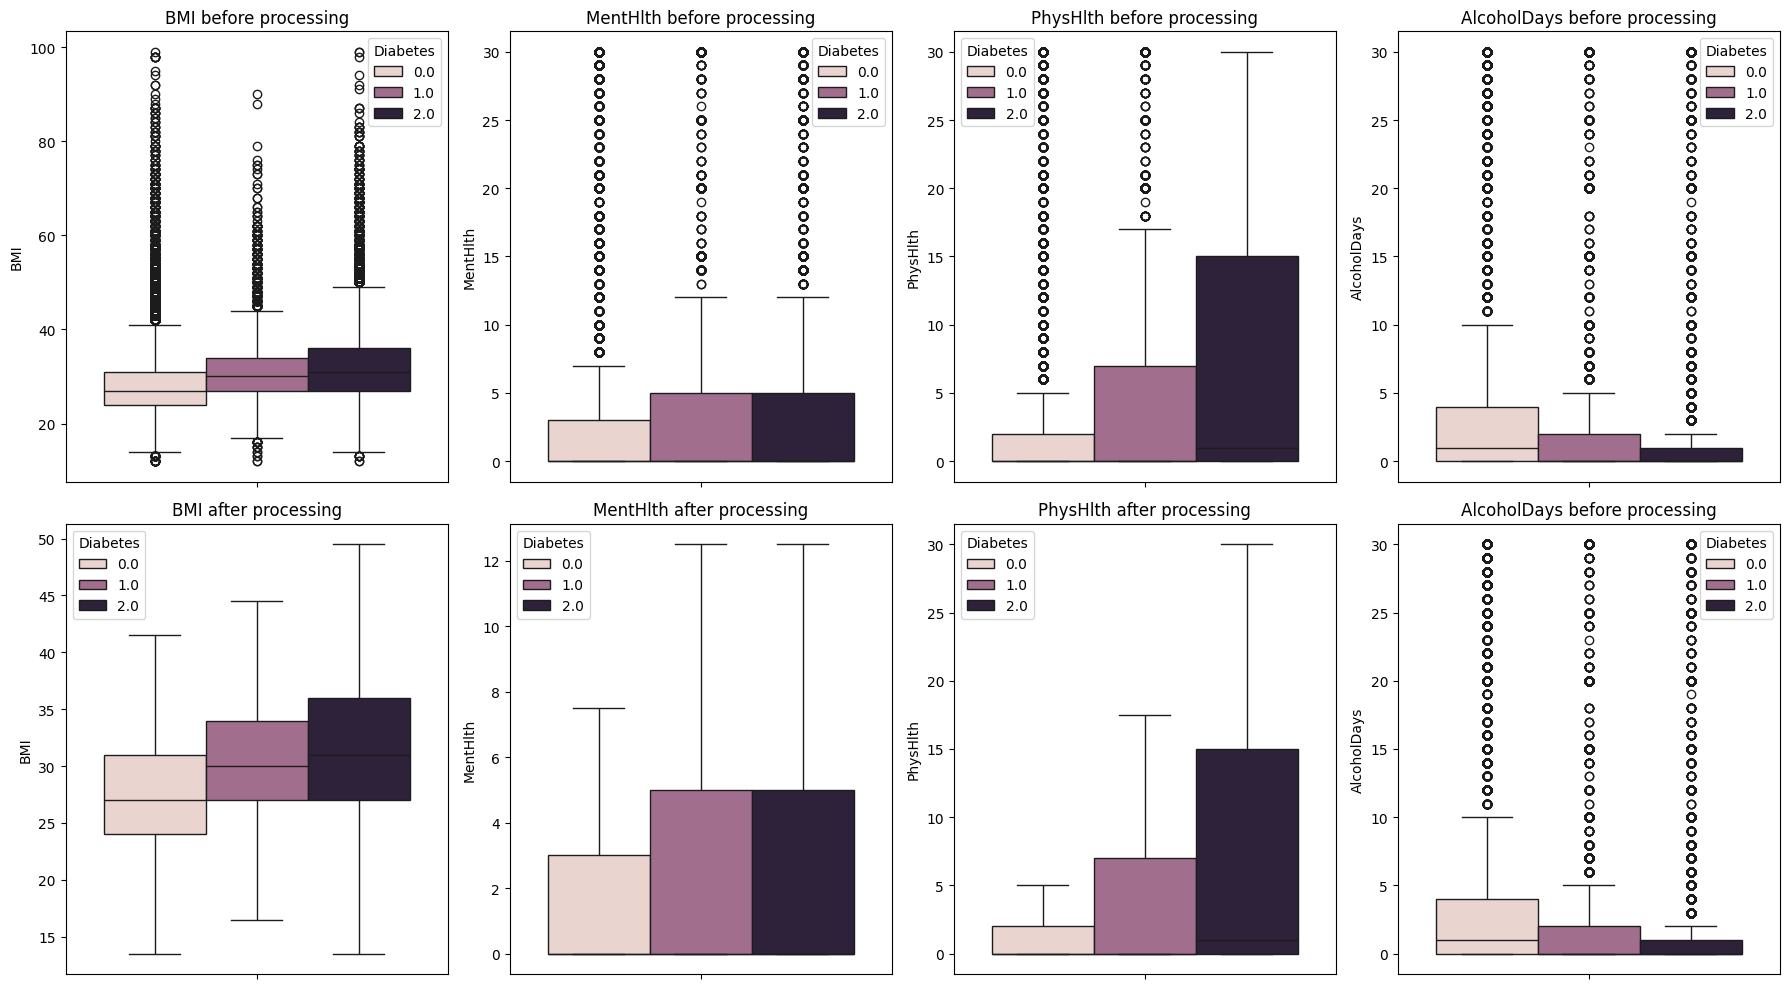

In [12]:
# Plot comparison chart before and after processing
fig, axes = plt.subplots(2, 4, figsize=(18, 10))

# Before processing
sns.boxplot(data=no_dup_df, y='BMI', hue='Diabetes', ax=axes[0,0])
axes[0, 0].set_title('BMI before processing')
sns.boxplot(data=no_dup_df, y='MentHlth', hue='Diabetes', ax=axes[0,1])
axes[0, 1].set_title('MentHlth before processing')
sns.boxplot(data=no_dup_df, y='PhysHlth', hue='Diabetes', ax=axes[0,2])
axes[0, 2].set_title('PhysHlth before processing')
sns.boxplot(data=no_dup_df, y='AlcoholDays', hue='Diabetes', ax=axes[0,3])
axes[0, 3].set_title('AlcoholDays before processing')

# After processing
sns.boxplot(data=outliers_df, y='BMI', hue='Diabetes', ax=axes[1,0])
axes[1, 0].set_title('BMI after processing')
sns.boxplot(data=outliers_df, y='MentHlth', hue='Diabetes', ax=axes[1,1])
axes[1, 1].set_title('MentHlth after processing')
sns.boxplot(data=outliers_df, y='PhysHlth', hue='Diabetes', ax=axes[1,2])
axes[1, 2].set_title('PhysHlth after processing')
sns.boxplot(data=no_dup_df, y='AlcoholDays', hue='Diabetes', ax=axes[1,3])
axes[1, 3].set_title('AlcoholDays before processing')

plt.tight_layout()
plt.show()

### **2.4 Exploratory Data Analysis**

#### **2.4.1 Healthy score**

---

Sum the health-related components (if present):

* `GenHlth`: General health rating (from 1 = excellent to 5 = poor)
* `MentHlth`: Number of days mental health was not good (0–30)
* `PhysHlth`: Number of days physical health was not good (0–30)
* `DiffWalk`: Difficulty walking (1 = Yes, 0 = No)

Each component is normalized or scaled:

* `GenHlth` is divided by 5
* `MentHlth` is divided by 30
* `PhysHlth` is divided by 30
* `DiffWalk` is multiplied by 0.5 (penalty for walking difficulty)

---

**Mathematical expression:**

Assume:

* $GH$: General Health (1 to 5)
* $MH$: Mental Health days (0 to 30)
* $PH$: Physical Health days (0 to 30)
* $DW$: Difficulty Walking (1 or 0)

We have the formula:

$$
HealthScore = \frac{GH}{5} + \frac{MH}{30} + \frac{PH}{30} + 0.5 \times DW
$$

---

**Illustrative example:**

Suppose a person has:

* General health: 4
* Days of poor mental health: 10
* Days of poor physical health: 5
* Difficulty walking: Yes (1)

Apply the formula:

$$
HealthScore = \frac{4}{5} + \frac{10}{30} + \frac{5}{30} + 0.5 = 0.8 + 0.333 + 0.167 + 0.5 = 1.8
$$


In [13]:
# Create a composite health score
hlth_score_df = diabetes_feature_engineering.create_health_score(df=outliers_df)

2025-09-27 20:47:34,434 - [src.features] - INFO - Creating enhanced health score feature...
2025-09-27 20:47:34,463 - [src.features] - INFO - Using columns for health score: ['GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk']
2025-09-27 20:47:34,474 - [src.features] - INFO - Enhanced health score created using 4 features. Range: [0.200, 2.917]


In [14]:
# Display unique values of HlthScore feature
hlth_score_df["HlthScore"].unique()

array([0.9       , 0.6       , 1.1       , 1.26666667, 0.4       ,
       1.3       , 1.46666667, 0.76666667, 2.58333333, 0.66666667,
       1.51666667, 0.53333333, 0.46666667, 0.65      , 1.8       ,
       0.63333333, 1.53333333, 0.86666667, 1.21666667, 0.2       ,
       0.43333333, 2.5       , 1.68333333, 0.7       , 1.71666667,
       0.96666667, 0.8       , 1.33333333, 0.73333333, 0.56666667,
       1.15      , 1.6       , 1.66666667, 1.5       , 1.16666667,
       1.13333333, 1.7       , 1.        , 2.11666667, 0.93333333,
       1.48333333, 1.73333333, 0.93333333, 0.85      , 2.56666667,
       2.41666667, 1.56666667, 1.4       , 1.91666667, 1.95      ,
       1.18333333, 2.88333333, 2.91666667, 1.06666667, 0.83333333,
       1.36666667, 2.53333333, 2.25      , 0.23333333, 0.76666667,
       1.41666667, 1.43333333, 0.95      , 0.81666667, 1.38333333,
       2.1       , 0.3       , 0.98333333, 0.36666667, 1.88333333,
       0.8       , 1.01666667, 0.5       , 2.6       , 2.01666

#### **2.4.2 Risk score**

---

Sum the available chronic disease risk factors:

* `HighBP`: High blood pressure (1 = Yes, 0 = No)
* `HighChol`: High cholesterol
* `HeartDiseaseorAttack`: Any heart disease or heart attack
* `Stroke`: History of stroke
* `DiagnosedHeartAttack`: Ever diagnosed with myocardial infarction
* `CoronaryHeartDisease`: Coronary artery disease
* `COPD`: Chronic obstructive pulmonary disease
* `KidneyDisease`: Chronic kidney disease

Each variable contributes **1 point** if present and equal to 1.

---

**Mathematical expression:**

Assume:

* $H_{BP}$: High Blood Pressure
* $H_{Chol}$: High Cholesterol
* $HDA$: Heart Disease or Heart Attack
* $S$: Stroke
* $DHA$: Diagnosed Heart Attack
* $CHD$: Coronary Heart Disease
* $C$: COPD
* $KD$: Kidney Disease

Each variable is either 0 or 1. Then:

$$
RiskScore = H_{BP} + H_{Chol} + HDA + S + DHA + CHD + C + KD
$$

---

**Illustrative example:**

Suppose a person has:

* High blood pressure: 1
* High cholesterol: 1
* Heart disease/attack: 1
* Stroke: 0
* Diagnosed heart attack: 1
* Coronary artery disease: 0
* COPD: 1
* Kidney disease: 0

Apply the formula:

$$
RiskScore = 1 + 1 + 1 + 0 + 1 + 0 + 1 + 0 = 5
$$

In [15]:
# Create a risk score
risk_score_df = diabetes_feature_engineering.create_risk_score(df=hlth_score_df)

2025-09-27 20:47:34,496 - [src.features] - INFO - Creating enhanced comprehensive risk score feature...
2025-09-27 20:47:34,572 - [src.features] - INFO - Using 8 risk factors: ['HighBP', 'HighChol', 'HeartDiseaseorAttack', 'Stroke', 'DiagnosedHeartAttack', 'CoronaryHeartDisease', 'COPD', 'KidneyDisease']
2025-09-27 20:47:34,616 - [src.features] - INFO - Enhanced risk score created successfully. Range: [0.0, 8.0]


In [16]:
# Display unique values of RiskScore feature
risk_score_df["RiskScore"].unique()

array([2., 4., 1., 3., 7., 5., 6., 8., 0.])

#### **2.4.3 Lifestyle score**

---

Combine lifestyle-related behaviors:

**Positive factor:**

* `PhysActivity`: Physically active (1 = Yes, 0 = No)

**Negative factors (one or more of the following):**

* `AlcoholDays`: Number of days in the past 30 that alcohol was consumed (0–30)
* `HvyAlcoholConsump`: Heavy alcohol consumption (1 = Yes, 0 = No) — *used only if `AlcoholDays` is not available*
* `Smoker`: Currently smokes (1 = Yes, 0 = No)

---

**Mathematical expression:**

Assume:

* $PA$: Physical activity (1 or 0)
* $AD$: Alcohol consumption days (0–30)
* $HAC$: Heavy alcohol consumption (1 or 0)
* $SM$: Smoker (1 or 0)

Then:

$$
LifestyleScore = PA - AlcoholPenalty - SM
$$

Where:

$$
AlcoholPenalty =
\begin{cases}
\frac{AD}{30}, & \text{if } AlcoholDays \text{ is available} \\
HAC, & \text{else if } HvyAlcoholConsump \text{ is available} \\
0, & \text{otherwise}
\end{cases}
$$

$$
SM =
\begin{cases}
1, & \text{if } Smoker = 1 \\
0, & \text{otherwise}
\end{cases}
$$

---

**Illustrative example:**

Suppose a person has:

* Physically active: 1
* AlcoholDays = 15
* Smoker: 1

Then:

$$
LifestyleScore = 1 - \frac{15}{30} - 1 = 1 - 0.5 - 1 = -0.5
$$

In [17]:
# Create lifestyle score
life_style_df = diabetes_feature_engineering.create_lifestyle_score(df=risk_score_df)

2025-09-27 20:47:34,638 - [src.features] - INFO - Creating enhanced lifestyle score feature...
2025-09-27 20:47:34,744 - [src.features] - INFO - Enhanced lifestyle score created using 1 positive and 2 negative factors
2025-09-27 20:47:34,747 - [src.features] - INFO - Range: [-1.333, 1.000]


In [18]:
# Display unique values of LifestyleScore feature
life_style_df["LifestyleScore"].unique()

array([ 1.        ,  0.        , -1.03333333, -0.03333333, -0.06666667,
       -1.16666667, -1.        ,  0.86666667, -1.1       , -0.13333333,
       -0.16666667, -0.33333333,  0.96666667, -0.1       , -0.23333333,
        0.9       , -0.03333333, -0.06666667, -1.23333333,  0.93333333,
       -1.13333333,  0.66666667, -1.08333333, -1.33333333, -0.16666667,
       -1.06666667, -0.13333333, -0.08333333, -0.33333333, -0.1       ,
        0.8       , -0.08333333,  0.83333333, -1.26666667, -0.23333333,
        0.91666667,  0.76666667, -0.26666667, -0.2       , -1.2       ,
       -0.26666667,  0.73333333, -0.2       ,  0.7       , -0.3       ,
       -1.3       , -0.3       ])

#### **2.4.4 Cardio risk**

---

Sum the cardiovascular risk variables:

* `HighBP`: High blood pressure (1 = Yes, 0 = No)
* `HighChol`: High cholesterol
* `DiagnosedHeartAttack`: Ever diagnosed with myocardial infarction
* `CoronaryHeartDisease`: Coronary artery disease

If there is a `BMI` column, add 1 point if **BMI > 30** (obesity index)

---

**Mathematical expression:**

Assume:

* $H_{BP}$: High Blood Pressure (1 or 0)
* $H_{Chol}$: High Cholesterol (1 or 0)
* $DHA$: Diagnosed Heart Attack (1 or 0)
* $CHD$: Coronary Heart Disease (1 or 0)
* $BMI$: Body Mass Index (actual value)

We have the formula formula:

$$
CardioRisk = H_{BP} + H_{Chol} + DHA + CHD + ObesityIndicator
$$

Where:

$$
ObesityIndicator =
\begin{cases}
1, & \text{if } BMI > 30 \\
0, & \text{if } BMI \leq 30 \text{ or no BMI}
\end{cases}
$$

---

**Illustrative example:**

Suppose a person has:

* High blood pressure: 1
* High cholesterol: 0
* Previous myocardial infarction: 1
* Coronary artery disease: 1
* BMI = 32

Apply the formula:

$$
CardioRisk = 1 + 0 + 1 + 1 + 1 = 4
$$

In [19]:
# Create a cardio risk score
cardio_risk_df = diabetes_feature_engineering.create_cardio_risk(df=life_style_df)

2025-09-27 20:47:34,768 - [src.features] - INFO - Creating enhanced cardiovascular risk feature...
2025-09-27 20:47:34,850 - [src.features] - INFO - Enhanced cardiovascular risk created using: ['HighBP', 'HighChol', 'DiagnosedHeartAttack', 'CoronaryHeartDisease', 'BMI_Obesity']
2025-09-27 20:47:34,855 - [src.features] - INFO - Range: [0.0, 5.0]


In [20]:
# Display unique values of CardioRisk feature
cardio_risk_df["CardioRisk"].unique()

array([2., 4., 1., 3., 5., 0.])

#### **2.4.5 Healthcare access**

---

Combine healthcare access and utilization indicators:

**Positive factors:**

* `AnyHealthcare`: Has any form of health coverage (1 = Yes, 0 = No)
* `HasPersonalDoctor`: Has a personal doctor or healthcare provider (1 = Yes, 0 = No)

**Negative factors:**

* `NoDocbcCost`: Could not see a doctor because of cost (1 = Yes, 0 = No)
* `CannotAffordDoctor`: General indicator for inability to afford a doctor (1 = Yes, 0 = No)

**Utilization factor:**

* `LastCheckup`: Time since last routine checkup (0 = within past year, higher = longer ago)

  * Lower values are better
  * Transformed so that recent checkups contribute positively

---

**Mathematical expression:**

Assume:

* $HC$: AnyHealthcare (1 or 0)
* $PD$: HasPersonalDoctor (1 or 0)
* $NC$: NoDocbcCost (1 or 0)
* $CAD$: CannotAffordDoctor (1 or 0)
* $LC$: LastCheckup (integer, 0 = most recent)
* $LC_{\text{max}}$: Maximum value of LastCheckup in the dataset

Then:

$$
HealthcareAccessScore = HC + PD - NC - CAD + \left( \frac{LC_{\text{max}} - LC}{LC_{\text{max}}} \right)
$$

* The checkup term increases the score if the last checkup was more recent (i.e., lower value of $LC$)
* All missing features are treated as zero if not present

---

**Illustrative example:**

Suppose a person has:

* Has health insurance: 1
* Has a personal doctor: 1
* Could not see doctor due to cost: 0
* Cannot afford doctor: 1
* LastCheckup = 1
* $LC_{\text{max}} = 5$

Apply the formula:

$$
HealthcareAccessScore = 1 + 1 - 0 - 1 + \left( \frac{5 - 1}{5} \right) = 1 + 0.8 = 1.8
$$

In [21]:
# Create healthcare access score
healthcare_access_df = diabetes_feature_engineering.create_healthcare_access_score(df=cardio_risk_df)

2025-09-27 20:47:34,875 - [src.features] - INFO - Creating healthcare access score feature...
2025-09-27 20:47:35,061 - [src.features] - INFO - Healthcare access score created using: ['AnyHealthcare', 'HasPersonalDoctor', 'NoDocbcCost', 'CannotAffordDoctor', 'LastCheckup']
2025-09-27 20:47:35,063 - [src.features] - INFO - Range: [-2.000, 3.000]


In [22]:
# Display unique values of HealthcareAccessScore feature
healthcare_access_df["HealthcareAccessScore"].unique()

array([ 2.33333333,  2.66666667,  1.66666667,  0.66666667,  2.        ,
        1.        ,  1.33333333, -0.33333333,  3.        , -0.66666667,
        0.33333333, -1.        ,  0.        , -1.33333333, -2.        ,
       -1.66666667])

#### **2.4.6 Socioeconomic score**

---

1. Combine normalized socioeconomic indicators:

**Included factors (if available):**

* `Education`: Highest level of education attained
* `Income`: Income category (higher values = higher income)
* `EmploymentStatus`: Current employment situation (ordinal scale)
* `MaritalStatus`: Marital status, **reversed scale** where "Married" is highest

Each factor is **normalized** by dividing by its **maximum possible value**, to bring all inputs onto a similar scale.

---

**Mathematical expression:**

Assume:

* $E$: Education
* $I$: Income
* $ES$: EmploymentStatus
* $MS$: MaritalStatus (original coded 1 to 6)

Let:

* $E_{\text{max}} = \max(E)$ in the dataset
* $I_{\text{max}} = \max(I)$ in the dataset
* $ES_{\text{max}} = \max(ES)$ in the dataset

The reversed marital status score is:

$$
MS_{\text{rev}} = \frac{7 - MS}{6}
$$

The overall socioeconomic score is calculated as:

$$
SocioeconomicScore = \frac{E}{E_{\text{max}}} + \frac{I}{I_{\text{max}}} + \frac{ES}{ES_{\text{max}}} + MS_{\text{rev}}
$$

*Only includes components available in the dataset.*

---

**Illustrative example:**

Suppose a person has:

* Education = 4, $E_{\text{max}} = 6$
* Income = 5, $I_{\text{max}} = 11$
* EmploymentStatus = 2, $ES_{\text{max}} = 8$
* MaritalStatus = 1 (Married)

Calculate:

$$
MS_{\text{rev}} = \frac{7 - 1}{6} = 1.0
$$

Then:

$$
SocioeconomicScore = \frac{4}{6} + \frac{5}{11} + \frac{2}{8} + 1.0 = 0.667 + 0.455 + 0.25 + 1.0 = 2.372
$$

---

**Note:**

* This reversal makes "Married" the highest contributor to the socioeconomic score, reflecting common interpretations of marital status impact.

In [23]:
# Create socioeconomic score
soci_score_df = diabetes_feature_engineering.create_socioeconomic_score(df=healthcare_access_df)

2025-09-27 20:47:35,088 - [src.features] - INFO - Creating socioeconomic score feature...
2025-09-27 20:47:35,183 - [src.features] - INFO - Socioeconomic score created using: ['Education', 'Income', 'EmploymentStatus', 'MaritalStatus']
2025-09-27 20:47:35,187 - [src.features] - INFO - Range: [0.549, 4.000]


In [24]:
# Display unique values of SocioeconomicScore feature
soci_score_df["SocioeconomicScore"].unique()

array([3.08712121, 1.64015152, 2.48863636, 2.92045455, 3.1780303 ,
       2.75378788, 2.4280303 , 2.00378788, 2.14772727, 2.4280303 ,
       2.99621212, 2.95454545, 3.03030303, 3.60227273, 3.10227273,
       2.17045455, 2.42424242, 2.68560606, 2.84469697, 2.85227273,
       1.83712121, 2.40530303, 3.26893939, 3.16287879, 2.51515152,
       2.46212121, 2.64772727, 3.32954545, 2.72348485, 2.48106061,
       2.68181818, 1.93181818, 3.34469697, 2.41287879, 1.74621212,
       2.81060606, 2.90530303, 3.0719697 , 3.18560606, 2.73863636,
       1.88636364, 1.56439394, 1.91287879, 3.12121212, 3.23863636,
       2.89015152, 2.55681818, 3.37878788, 1.89772727, 2.6969697 ,
       1.96590909, 3.51136364, 2.13257576, 2.75378788, 3.01136364,
       3.26136364, 1.9280303 , 2.97727273, 2.50378788, 2.59090909,
       2.25378788, 1.21590909, 2.39772727, 3.43560606, 2.66287879,
       3.25378788, 2.88636364, 3.01893939, 2.22348485, 2.20454545,
       2.41287879, 2.5719697 , 2.31439394, 3.1969697 , 3.28787

#### **2.4.7 Cholesterol management**

---

Define cholesterol management factors:

* `CholCheck`: Indicator if cholesterol is regularly checked (1 = Yes, 0 = No) — **positive factor**
* `CholesterolMeds`: Indicator if taking cholesterol medication (1 = Yes, 0 = No) — **positive factor**
* `HighChol`: Indicator if high cholesterol present (1 = Yes, 0 = No) — **risk factor / penalty**

---

Calculate cholesterol management score:

$$
ManagementScore = CholCheck + CholesterolMeds - HighChol \times \left(1 - 0.5 \times CholesterolMeds\right)
$$

Where:

* If cholesterol medication is taken, the penalty from high cholesterol is **reduced by half**.
* If no medication, full penalty for high cholesterol is applied.
* If `HighChol` is present but `CholesterolMeds` is missing, then:

$$
ManagementScore = CholCheck - HighChol
$$

---

**Interpretation:**

* Higher scores indicate **better cholesterol management**, combining regular checks and medication adherence.
* Presence of high cholesterol reduces the score, but less so if managed by medication.

---

**Illustrative example:**

Suppose a person has:

* `CholCheck` = 1 (regular check)
* `CholesterolMeds` = 1 (takes medication)
* `HighChol` = 1 (has high cholesterol)

Then:

$$
ManagementScore = 1 + 1 - 1 \times (1 - 0.5 \times 1) = 2 - 0.5 = 1.5
$$

If the person does **not** take medication (`CholesterolMeds` = 0), then:

$$
ManagementScore = 1 + 0 - 1 \times (1 - 0) = 1 - 1 = 0
$$

In [25]:
# Create cholesterol management score
choles_score_df = diabetes_feature_engineering.create_cholesterol_management_score(df=soci_score_df)

2025-09-27 20:47:35,220 - [src.features] - INFO - Creating cholesterol management score feature...
2025-09-27 20:47:35,318 - [src.features] - INFO - Cholesterol management score created using: ['CholCheck', 'HighChol', 'CholesterolMeds']
2025-09-27 20:47:35,322 - [src.features] - INFO - Range: [-1.000, 2.000]


In [26]:
# Display unique values of CholesterolManagementScore feature
choles_score_df["CholesterolManagementScore"].unique()

array([ 1.5,  0. , -1. ,  0.5,  1. ,  2. ])

#### **2.4.8 Mental health**

---

Define mental health factors:

* `Depression`: Indicator of depression (1 = Yes, 0 = No) — **negative factor**
* `CognitiveIssues`: Indicator of cognitive problems (1 = Yes, 0 = No) — **negative factor**
* `MentHlth`: Number of days with poor mental health in past 30 days — **negative factor (normalized)**

---

Calculate comprehensive mental health score:

$$
MentalHealthScore = -Depression - CognitiveIssues - \frac{MentHlth}{30}
$$

Where:

* Each factor **decreases** the mental health score.
* `MentHlth` is normalized by dividing by 30 to scale the days into a 0–1 range.

---

**Interpretation:**

* Lower (more negative) scores indicate **worse mental health**.
* Higher scores (closer to zero) indicate better mental health status.

---

**Illustrative example:**

Suppose a person has:

* `Depression` = 1 (depressed)
* `CognitiveIssues` = 0 (no cognitive issues)
* `MentHlth` = 10 days of poor mental health in past 30 days

Then:

$$
MentalHealthScore = -1 - 0 - \frac{10}{30} = -1 - 0 - 0.333 = -1.333
$$

In [27]:
# Create mental health score
mental_hlth_df = diabetes_feature_engineering.create_mental_health_score(df=choles_score_df)

2025-09-27 20:47:35,347 - [src.features] - INFO - Creating comprehensive mental health score feature...
2025-09-27 20:47:35,446 - [src.features] - INFO - Comprehensive mental health score created using: ['Depression', 'CognitiveIssues', 'MentHlth']
2025-09-27 20:47:35,449 - [src.features] - INFO - Range: [-2.417, 0.000]


In [28]:
# Display unique values of MentalHealthScore feature
mental_hlth_df["MentalHealthScore"].unique()

array([ 0.        , -1.        , -2.        , -1.03333333, -0.41666667,
       -2.06666667, -2.25      , -0.25      , -0.03333333, -0.06666667,
       -0.2       , -2.41666667, -2.03333333, -0.16666667, -1.25      ,
       -1.06666667, -1.13333333, -2.23333333, -0.13333333, -1.16666667,
       -1.41666667, -1.1       , -1.4       , -0.1       , -2.16666667,
       -1.23333333, -2.1       , -2.33333333, -2.2       , -0.23333333,
       -0.33333333, -1.2       , -2.13333333, -1.26666667, -1.33333333,
       -0.26666667, -2.26666667, -1.3       , -2.36666667, -2.4       ,
       -0.3       , -0.4       , -1.36666667, -2.3       , -0.36666667])

### **2.5 Creating category features**

#### **2.5.1 BMI category**

In [29]:
bmi_category_df = diabetes_feature_engineering.create_bmi_category(df=mental_hlth_df)

2025-09-27 20:47:35,479 - [src.features] - INFO - Creating BMI category feature...
2025-09-27 20:47:35,695 - [src.features] - INFO - BMI category distribution:
2025-09-27 20:47:35,696 - [src.features] - INFO -   - Pre-obesity: 163017 (36.29%)
2025-09-27 20:47:35,697 - [src.features] - INFO -   - Obesity class I: 107175 (23.86%)
2025-09-27 20:47:35,697 - [src.features] - INFO -   - Normal weight: 99203 (22.08%)
2025-09-27 20:47:35,698 - [src.features] - INFO -   - Obesity class II: 45231 (10.07%)
2025-09-27 20:47:35,699 - [src.features] - INFO -   - Obesity class III: 29862 (6.65%)
2025-09-27 20:47:35,699 - [src.features] - INFO -   - Underweight: 4717 (1.05%)


In [30]:
bmi_category_df["BMICategory"].unique()

array(['Pre-obesity', 'Normal weight', 'Obesity class I',
       'Obesity class II', 'Obesity class III', 'Underweight'],
      dtype=object)

#### **2.5.2 Age group**

In [31]:
age_group_df = diabetes_feature_engineering.create_age_group(df=bmi_category_df)

2025-09-27 20:47:35,751 - [src.features] - INFO - Creating enhanced age group feature...
2025-09-27 20:47:35,892 - [src.features] - INFO - Age-Sex distribution analysis:
2025-09-27 20:47:35,940 - [src.features] - INFO -   - Middle-Sex0.0: 81318
2025-09-27 20:47:35,941 - [src.features] - INFO -   - Middle-Sex1.0: 84992
2025-09-27 20:47:35,941 - [src.features] - INFO -   - Middle-Sex9.0: 1
2025-09-27 20:47:35,942 - [src.features] - INFO -   - Senior-Sex0.0: 114689
2025-09-27 20:47:35,943 - [src.features] - INFO -   - Senior-Sex1.0: 131791
2025-09-27 20:47:35,943 - [src.features] - INFO -   - Senior-Sex9.0: 10
2025-09-27 20:47:35,944 - [src.features] - INFO -   - Young-Sex0.0: 18851
2025-09-27 20:47:35,944 - [src.features] - INFO -   - Young-Sex1.0: 17553
2025-09-27 20:47:35,946 - [src.features] - INFO -   - Young-Sex9.0: 0
2025-09-27 20:47:35,969 - [src.features] - INFO - Age group distribution:
2025-09-27 20:47:35,970 - [src.features] - INFO -   - Senior: 246490 (54.87%)
2025-09-27 20:4

In [32]:
age_group_df["AgeGroup"].unique()

array(['Senior', 'Middle', 'Young'], dtype=object)

### **2.6 Encoding category values**

In [33]:
age_group_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 449205 entries, 0 to 452654
Data columns (total 43 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Diabetes                    449205 non-null  float64
 1   HighBP                      449205 non-null  float64
 2   HighChol                    449205 non-null  float64
 3   CholCheck                   449205 non-null  float64
 4   BMI                         449205 non-null  float64
 5   Smoker                      449205 non-null  float64
 6   Stroke                      449205 non-null  float64
 7   HeartDiseaseorAttack        449205 non-null  float64
 8   PhysActivity                449205 non-null  float64
 9   HvyAlcoholConsump           449205 non-null  float64
 10  AnyHealthcare               449205 non-null  float64
 11  NoDocbcCost                 449205 non-null  float64
 12  GenHlth                     449205 non-null  float64
 13  MentHlth           

In [34]:
# Convert categorical features to numerical using label encoding
# BMICategory: Normal weight=0, Obesity I=1, etc.
# AgeGroup: Middle=0, Senior=1, Young=2
encoded_df, encoders = diabetes_feature_engineering.encode_categorical_features(df=age_group_df)

2025-09-27 20:47:36,164 - [src.features] - INFO - Starting enhanced categorical feature encoding...
2025-09-27 20:47:36,215 - [src.features] - INFO - Found 2 categorical columns to encode: ['BMICategory', 'AgeGroup']
2025-09-27 20:47:36,216 - [src.features] - INFO - Encoding column: BMICategory
2025-09-27 20:47:36,282 - [src.features] - INFO -   - Encoding mapping: {'Normal weight': 0, 'Obesity class I': 1, 'Obesity class II': 2, 'Obesity class III': 3, 'Pre-obesity': 4, 'Underweight': 5}
2025-09-27 20:47:36,282 - [src.features] - INFO - Encoding column: AgeGroup
2025-09-27 20:47:36,346 - [src.features] - INFO -   - Encoding mapping: {'Middle': 0, 'Senior': 1, 'Young': 2}
2025-09-27 20:47:36,347 - [src.features] - INFO - Categorical feature encoding completed for 2 columns


In [35]:
encoded_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 449205 entries, 0 to 452654
Data columns (total 43 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Diabetes                    449205 non-null  float64
 1   HighBP                      449205 non-null  float64
 2   HighChol                    449205 non-null  float64
 3   CholCheck                   449205 non-null  float64
 4   BMI                         449205 non-null  float64
 5   Smoker                      449205 non-null  float64
 6   Stroke                      449205 non-null  float64
 7   HeartDiseaseorAttack        449205 non-null  float64
 8   PhysActivity                449205 non-null  float64
 9   HvyAlcoholConsump           449205 non-null  float64
 10  AnyHealthcare               449205 non-null  float64
 11  NoDocbcCost                 449205 non-null  float64
 12  GenHlth                     449205 non-null  float64
 13  MentHlth           

### **2.6 Feature selection**

In [36]:
encoded_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 449205 entries, 0 to 452654
Data columns (total 43 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Diabetes                    449205 non-null  float64
 1   HighBP                      449205 non-null  float64
 2   HighChol                    449205 non-null  float64
 3   CholCheck                   449205 non-null  float64
 4   BMI                         449205 non-null  float64
 5   Smoker                      449205 non-null  float64
 6   Stroke                      449205 non-null  float64
 7   HeartDiseaseorAttack        449205 non-null  float64
 8   PhysActivity                449205 non-null  float64
 9   HvyAlcoholConsump           449205 non-null  float64
 10  AnyHealthcare               449205 non-null  float64
 11  NoDocbcCost                 449205 non-null  float64
 12  GenHlth                     449205 non-null  float64
 13  MentHlth           

In [37]:
# Select features with correlation > 0.1 with target variable
# Reduces dimensionality while retaining predictive power
selected_features = diabetes_feature_engineering.feature_selection(df=encoded_df)
final_df = encoded_df[selected_features]

2025-09-27 20:47:36,481 - [src.features] - INFO - Starting enhanced feature selection process...
2025-09-27 20:47:36,483 - [src.features] - INFO - Target column: Diabetes
2025-09-27 20:47:36,487 - [src.features] - INFO - Correlation threshold: 0.05
2025-09-27 20:47:39,062 - [src.features] - INFO - Selected 33 features (+ target column) out of 42 available
2025-09-27 20:47:39,062 - [src.features] - INFO - Top 10 selected features by correlation:
2025-09-27 20:47:39,063 - [src.features] - INFO -   - PhysHlth: 0.4401 (|0.4401|)
2025-09-27 20:47:39,064 - [src.features] - INFO -   - HlthScore: 0.3969 (|0.3969|)
2025-09-27 20:47:39,064 - [src.features] - INFO -   - CardioRisk: 0.3386 (|0.3386|)
2025-09-27 20:47:39,065 - [src.features] - INFO -   - RiskScore: 0.3054 (|0.3054|)
2025-09-27 20:47:39,066 - [src.features] - INFO -   - GenHlth: 0.3029 (|0.3029|)
2025-09-27 20:47:39,067 - [src.features] - INFO -   - CholesterolMeds: 0.2956 (|0.2956|)
2025-09-27 20:47:39,068 - [src.features] - INFO -

In [38]:
final_df.columns

Index(['HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke',
       'HeartDiseaseorAttack', 'PhysActivity', 'HvyAlcoholConsump', 'GenHlth',
       'MentHlth', 'PhysHlth', 'DiffWalk', 'Age', 'Education', 'Income',
       'Depression', 'CognitiveIssues', 'KidneyDisease',
       'DiagnosedHeartAttack', 'CoronaryHeartDisease', 'COPD', 'AlcoholDays',
       'LastCheckup', 'HasPersonalDoctor', 'CholesterolMeds',
       'EmploymentStatus', 'HlthScore', 'RiskScore', 'LifestyleScore',
       'CardioRisk', 'CholesterolManagementScore', 'MentalHealthScore',
       'Diabetes'],
      dtype='object')

In [39]:
final_df.shape

(449205, 34)

In [40]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 449205 entries, 0 to 452654
Data columns (total 34 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   HighBP                      449205 non-null  float64
 1   HighChol                    449205 non-null  float64
 2   CholCheck                   449205 non-null  float64
 3   BMI                         449205 non-null  float64
 4   Smoker                      449205 non-null  float64
 5   Stroke                      449205 non-null  float64
 6   HeartDiseaseorAttack        449205 non-null  float64
 7   PhysActivity                449205 non-null  float64
 8   HvyAlcoholConsump           449205 non-null  float64
 9   GenHlth                     449205 non-null  float64
 10  MentHlth                    449205 non-null  float64
 11  PhysHlth                    449205 non-null  float64
 12  DiffWalk                    449205 non-null  float64
 13  Age                

In [41]:
final_df.describe().T

,count,mean,std,min,25%,50%,75%,max
HighBP,449205.0,0.508469,0.499929,0.000000,0.0,1.0,1.000000,1.000000
HighChol,449205.0,0.674848,0.468432,0.000000,0.0,1.0,1.000000,1.000000
CholCheck,449205.0,0.973101,0.161787,0.000000,1.0,1.0,1.000000,1.000000
BMI,449205.0,28.994741,5.880561,13.500000,25.0,28.0,32.000000,49.500000
Smoker,449205.0,0.447831,0.497272,0.000000,0.0,0.0,1.000000,1.000000
Stroke,449205.0,0.051446,0.220907,0.000000,0.0,0.0,0.000000,1.000000
HeartDiseaseorAttack,449205.0,0.117116,0.321559,0.000000,0.0,0.0,0.000000,1.000000
PhysActivity,449205.0,0.744740,0.436008,0.000000,0.0,1.0,1.000000,1.000000
HvyAlcoholConsump,449205.0,0.060482,0.238379,0.000000,0.0,0.0,0.000000,1.000000
GenHlth,449205.0,2.635625,1.058662,1.000000,2.0,3.0,3.000000,5.000000


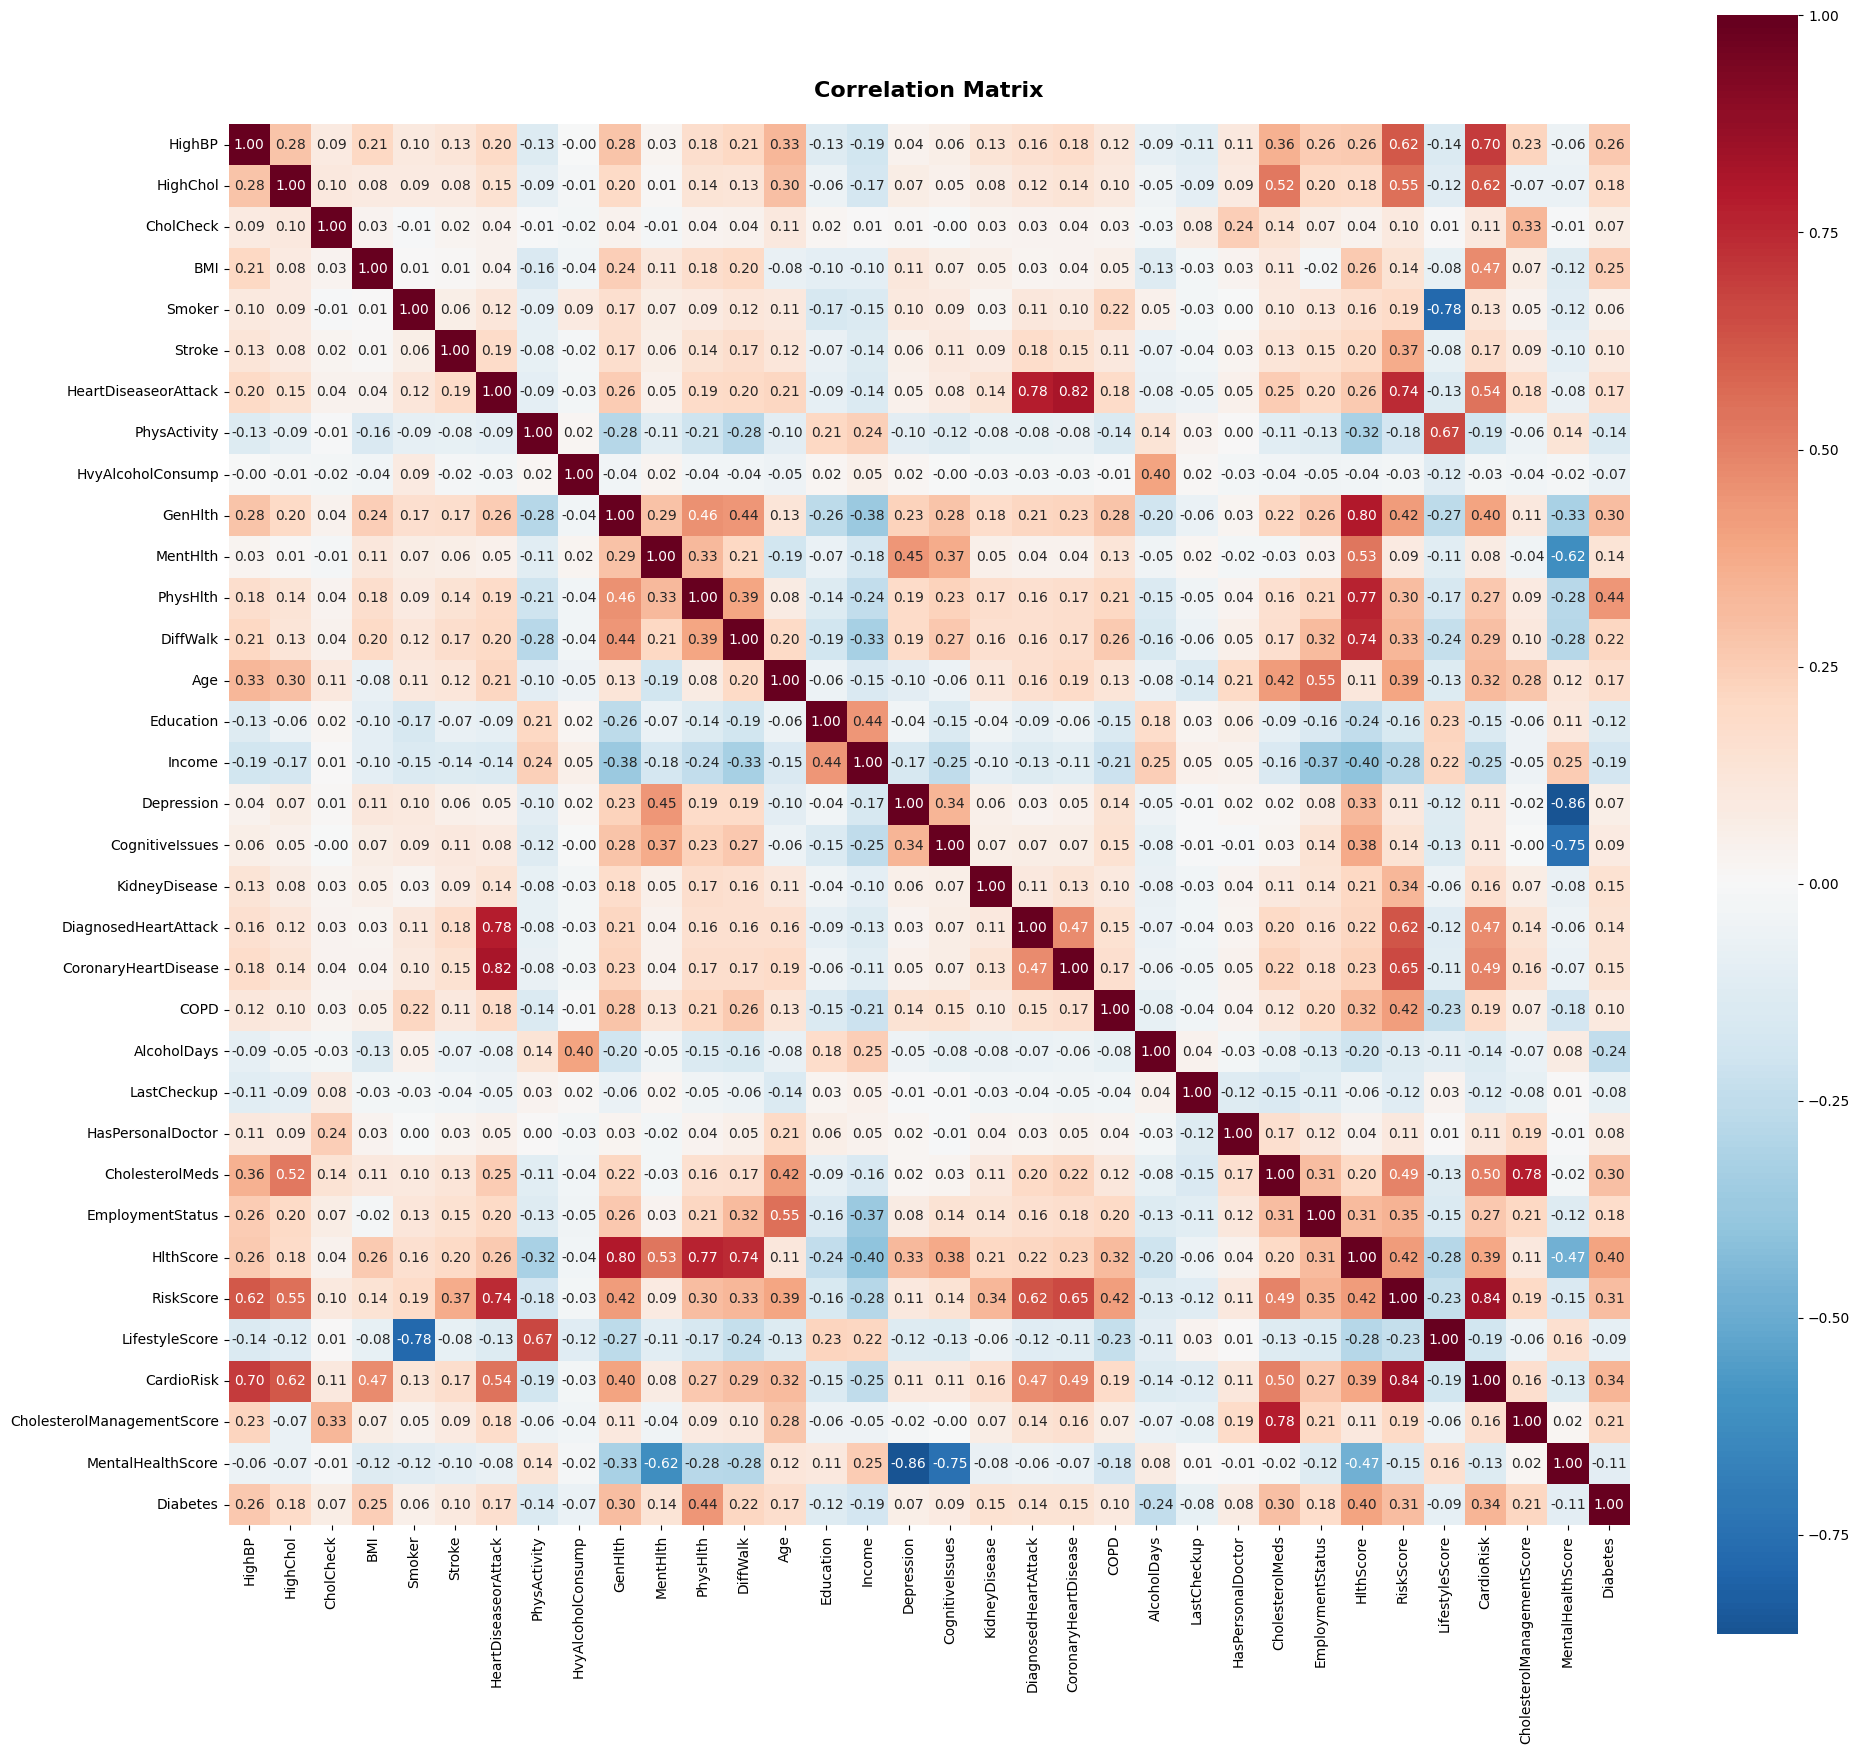

In [42]:
# Visualize feature correlations to identify potential multicollinearity
plot_correlation_matrix(df=final_df)